In [1]:
import os
import ast
import wfdb
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import layers, models, callbacks
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

# ==========================================
# 1. LETTURA DATASET E PREPARAZIONE DATI (codice fornito direttamente dai creatori di PTB-XL)
# ==========================================

def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data


path = '/Users/alessiorizzi/Desktop/env_tesi/dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'

sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

'''
# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass
'''


'\n# Split data into train and test\ntest_fold = 10\n# Train\nX_train = X[np.where(Y.strat_fold != test_fold)]\ny_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass\n# Test\nX_test = X[np.where(Y.strat_fold == test_fold)]\ny_test = Y[Y.strat_fold == test_fold].diagnostic_superclass\n'

In [20]:
# ==========================================
# 2. DIVISIONE TRA TRAIN, VALIDATION E TEST
# ==========================================
# Fold 1-8: Train | Fold 9: Validation | Fold 10: Test
test_fold = 10
val_fold = 9

X_train = X[(Y.strat_fold != test_fold) & (Y.strat_fold != val_fold)]
Y_train = Y_bin[(Y.strat_fold != test_fold) & (Y.strat_fold != val_fold)]

X_val = X[Y.strat_fold == val_fold]
Y_val = Y_bin[Y.strat_fold == val_fold]

X_test = X[Y.strat_fold == test_fold]
Y_test = Y_bin[Y.strat_fold == test_fold]

# Converti i segnali in float32
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# Normalizzazione Z-score (indispensabile calcolarla SOLO sul training set)
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("Inizio binarizzazione delle etichette")

# Binarizzazione delle etichette (Multi-label classification)
mlb = MultiLabelBinarizer()
Y_bin = mlb.fit_transform(Y['diagnostic_superclass'])
classes = mlb.classes_
print("Binarizzazione delle etichette completato")
print(f"Classi rilevate: {classes}")
# È buona norma convertire anche le etichette
Y_train = Y_train.astype(np.float32)
Y_val = Y_val.astype(np.float32)
Y_test = Y_test.astype(np.float32)

Inizio binarizzazione delle etichette
Binarizzazione delle etichette completato
Classi rilevate: ['CD' 'HYP' 'MI' 'NORM' 'STTC']


In [27]:
# Estrai solo la singola derivazione D1 (indice 0)
X_train = X_train[:, :, 0:1]
X_val = X_val[:, :, 0:1]
X_test = X_test[:, :, 0:1]

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")


X_train: (17418, 1000, 1)
X_val: (2183, 1000, 1)
X_test: (2198, 1000, 1)


In [28]:
# ==========================================
# 3. TECNICHE DI DATA AUGMENTATION (DA)
# ==========================================
# Nel paper si utilizza spesso l'aggiunta di rumore gaussiano e il drift della linea di base
# Implementiamo un layer di DA nativo di TensorFlow
def ecg_augmentation(signal, label):
    # Aggiunta di rumore Gaussiano (simula artefatti muscolari e termici)
    noise = tf.random.normal(shape=tf.shape(signal), mean=0.0, stddev=0.05, dtype=tf.float32)
    signal = signal + noise
    
    # Random Scaling (simula differenze di impedenza cutanea)
    scale = tf.random.uniform(shape=[1], minval=0.9, maxval=1.1, dtype=tf.float32)
    signal = signal * scale
    return signal, label

batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024).map(ecg_augmentation, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [45]:
# ==========================================
# 4. ARCHITETTURA (CNN Leggera < 100k parametri)
# ==========================================
# Architettura a 8 layer convoluzionali come descritta nel paper
def build_lightweight_cnn(input_shape=(1000, 1), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    
    # Configurazione degli 8 layer: filtri e kernel
    filters = [16, 16, 32, 32, 64, 64, 64, 64]
    kernels = [7, 7, 5, 5, 5, 3, 3, 3]
    
    for f, k in zip(filters, kernels):
        x = layers.Conv1D(filters=f, kernel_size=k, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x) # Previene l'overfitting
    
    # Attivazione Sigmoid perché è Multi-Label (una traccia può essere MI e CD contemporaneamente)
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = build_lightweight_cnn(input_shape=(1000, 1), num_classes=len(classes))
model.summary() # Verificherai che i parametri sono ~65.000, in linea con "< 100.000"

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 1000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_40 (Conv1D)              │ (None, 1000, 16)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 1000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_40 (ReLU)                 │ (None, 1000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_40 (MaxPooling1D) │ (None, 500, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_41 (Conv1D)              │ (None, 500, 16)        │         1,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 500, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_41 (ReLU)                 │ (None, 500, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_41 (MaxPooling1D) │ (None, 250, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_42 (Conv1D)              │ (None, 250, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 250, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_42 (ReLU)                 │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_42 (MaxPooling1D) │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_43 (Conv1D)              │ (None, 125, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 125, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_43 (ReLU)                 │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_43 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_44 (Conv1D)              │ (None, 62, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 62, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_44 (ReLU)                 │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_44 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_45 (Conv1D)              │ (None, 31, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 58,773 (229.58 KB)

 Trainable params: 58,069 (226.83 KB)

 Non-trainable params: 704 (2.75 KB)

In [46]:
# ==========================================
# 5. OTTIMIZZATORE, METRICHE E CALLBACKS
# ==========================================
# Ottimizzatore Adam standard per serie temporali
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Loss BinaryCrossentropy per classificazione multi-label
model.compile(optimizer=optimizer, 
              loss='binary_crossentropy', 
              metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True), 
                       tf.keras.metrics.BinaryAccuracy(name='accuracy')])

# Tecniche di diminuzione del learning rate e salvataggio pesi
callbacks_list = [
    # Riduce il LR se la loss in validation non migliora per 5 epoche
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
    # Ferma l'allenamento in anticipo se la rete va in overfitting
    callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1),
    # Salva il modello finale e i migliori pesi (best_model)
    callbacks.ModelCheckpoint(filepath='/Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

In [47]:
# ==========================================
# 6. TRAINING
# ==========================================
# Le epoche proposte nel paper o in letteratura per questa architettura variano, 50-70 è lo standard.
EPOCHS = 200 

print("Inizio fase di training...")
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

# Salvataggio Esplicito alla fine dell'addestramento
model.save('/Users/alessiorizzi/Desktop/env_tesi/model/final_ptbxl_d1_model.keras')
model.save_weights('/Users/alessiorizzi/Desktop/env_tesi/weights/final_ptbxl_d1_weights.weights.h5')
print("Modello e pesi salvati con successo.")

Inizio fase di training...
Epoch 1/200


/Users/alessiorizzi/Desktop/env_tesi/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7694 - auc: 0.7269 - loss: 0.5054
Epoch 1: val_loss improved from None to 0.42684, saving model to /Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model.keras

Epoch 1: finished saving model to /Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7694 - auc: 0.7269 - loss: 0.5053 - val_accuracy: 0.8086 - val_auc: 0.7984 - val_loss: 0.4268 - learning_rate: 0.0010
Epoch 2/200
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8116 - auc: 0.7904 - loss: 0.4273
Epoch 2: val_loss improved from 0.42684 to 0.41063, saving model to /Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model.keras

Epoch 2: finished saving model to /Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8116 - auc: 0.7904 - loss: 0.4274 - val_accuracy: 0.8224 - val_auc: 0.8158 - val_loss: 0.4106 - lea

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8250 - auc: 0.8228 - loss: 0.3983
Risultati sul Test Set (Fold 10) -> Loss: 0.3983 - AUC: 0.8228 - Accuracy: 0.8250


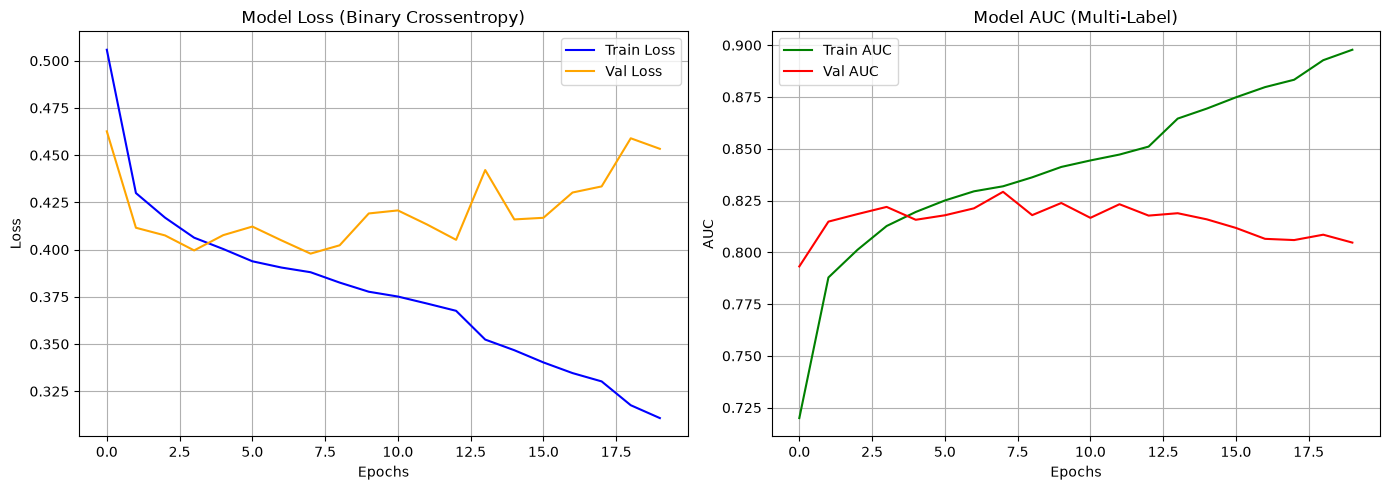

In [38]:
# ==========================================
# 7. VALUTAZIONE E GRAFICI (LOSS E ACCURACY)
# ==========================================
# Test finale sul Fold 10
test_loss, test_auc, test_acc = model.evaluate(test_dataset)
print(f"Risultati sul Test Set (Fold 10) -> Loss: {test_loss:.4f} - AUC: {test_auc:.4f} - Accuracy: {test_acc:.4f}")

# Funzione per plottare Loss e Accuracy (AUC e Binary Accuracy)
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafico della Loss
    ax1.plot(history.history['loss'], label='Train Loss', color='blue')
    ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
    ax1.set_title('Model Loss (Binary Crossentropy)')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Grafico dell'AUC
    ax2.plot(history.history['auc'], label='Train AUC', color='green')
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red')
    ax2.set_title('Model AUC (Multi-Label)')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('/Users/alessiorizzi/Desktop/env_tesi/training_curves.png', dpi=300)
    plt.show()

plot_history(history)

### Prova di distinzione tra la sola classe NORM e tutte le restanti. 


In [ ]:
def is_normal(superclasses):
    # Ritorna 1.0 se l'ECG è NORM e non ha altre patologie concorrenti
    if 'NORM' in superclasses and len(superclasses) == 1:
        return 1.0
    else:
        return 0.0 # È patologico

print("Creazione etichette binarie NORM vs ABNORM...")
Y_binary = Y['diagnostic_superclass'].apply(is_normal).values
Y_binary = Y_binary.astype(np.float32)

norm_count = np.sum(Y_binary == 1)
abnorm_count = np.sum(Y_binary == 0)
print(f"Tracciati Normali (1): {norm_count}")
print(f"Tracciati Anormali (0): {abnorm_count}")

# ==========================================
# 2. DIVISIONE TRA TRAIN, VALIDATION E TEST
# ==========================================
test_fold = 10
val_fold = 9

# Ora usiamo Y_binary per assegnare correttamente le etichette 0 e 1
X_train = X[(Y.strat_fold != test_fold) & (Y.strat_fold != val_fold)]
Y_train = Y_binary[(Y.strat_fold != test_fold) & (Y.strat_fold != val_fold)]

X_val = X[Y.strat_fold == val_fold]
Y_val = Y_binary[Y.strat_fold == val_fold]

X_test = X[Y.strat_fold == test_fold]
Y_test = Y_binary[Y.strat_fold == test_fold]

# ==========================================
# 3. ESTRAZIONE D1, CONVERSIONE E NORMALIZZAZIONE
# ==========================================
# Estrazione singola derivazione D1 (indice 0) e conversione a float32 per TF
X_train = X_train[:, :, 0:1].astype(np.float32)
X_val = X_val[:, :, 0:1].astype(np.float32)
X_test = X_test[:, :, 0:1].astype(np.float32)

# Normalizzazione Z-score (calcolata SOLO sul training set per evitare data leakage)
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

Creazione etichette binarie NORM vs ABNORM...
Tracciati Normali (1): 9069
Tracciati Anormali (0): 12730


In [5]:
# ==========================================
# 3. TECNICHE DI DATA AUGMENTATION (DA)
# ==========================================
# Nel paper si utilizza spesso l'aggiunta di rumore gaussiano e il drift della linea di base
# Implementiamo un layer di DA nativo di TensorFlow
def ecg_augmentation(signal, label):
    # Aggiunta di rumore Gaussiano (simula artefatti muscolari e termici)
    noise = tf.random.normal(shape=tf.shape(signal), mean=0.0, stddev=0.05, dtype=tf.float32)
    signal = signal + noise
    
    # Random Scaling (simula differenze di impedenza cutanea)
    scale = tf.random.uniform(shape=[1], minval=0.9, maxval=1.1, dtype=tf.float32)
    signal = signal * scale
    return signal, label

batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024).map(ecg_augmentation, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [6]:
# ==========================================
# 4. ARCHITETTURA (CNN Leggera < 100k parametri)
# ==========================================
# Architettura a 8 layer convoluzionali come descritta nel paper
def build_lightweight_cnn_binary(input_shape=(1000, 1)):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    
    filters = [16, 16, 32, 32, 64, 64, 64, 64]
    kernels = [7, 7, 5, 5, 5, 3, 3, 3]
    
    for f, k in zip(filters, kernels):
        x = layers.Conv1D(filters=f, kernel_size=k, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x) 
    
    # MODIFICA QUI: un singolo neurone di output con attivazione sigmoide
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = build_lightweight_cnn_binary(input_shape=(1000, 1))
model.summary() # Verificherai che i parametri sono ~65.000, in linea con "< 100.000"

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 16)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 1000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 500, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 16)        │         1,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 500, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 125, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 125, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 62, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 31, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 58,513 (228.57 KB)

 Trainable params: 57,809 (225.82 KB)

 Non-trainable params: 704 (2.75 KB)

In [7]:
# ==========================================
# 5. OTTIMIZZATORE, METRICHE E CALLBACKS
# ==========================================
# Ottimizzatore Adam standard per serie temporali
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Loss BinaryCrossentropy per classificazione multi-label
model.compile(optimizer=optimizer, 
              loss='binary_crossentropy', 
              metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True), 
                       tf.keras.metrics.BinaryAccuracy(name='accuracy')])

# Tecniche di diminuzione del learning rate e salvataggio pesi
callbacks_list = [
    # Riduce il LR se la loss in validation non migliora per 5 epoche
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
    # Ferma l'allenamento in anticipo se la rete va in overfitting
    callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1),
    # Salva il modello finale e i migliori pesi (best_model)
    callbacks.ModelCheckpoint(filepath='/Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model_NORM_vs_ALL.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

In [8]:
# ==========================================
# 6. TRAINING
# ==========================================
# Le epoche proposte nel paper o in letteratura per questa architettura variano, 50-70 è lo standard.
EPOCHS = 200 

print("Inizio fase di training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

# Salvataggio Esplicito alla fine dell'addestramento
model.save('/Users/alessiorizzi/Desktop/env_tesi/model/final_ptbxl_d1_model_NORM_vs_ALL.keras')
model.save_weights('/Users/alessiorizzi/Desktop/env_tesi/weights/final_ptbxl_d1_weights_NORM_vs_ALL.weights.h5')
print("Modello e pesi salvati con successo.")

Inizio fase di training...
Epoch 1/200


/Users/alessiorizzi/Desktop/env_tesi/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


271/273 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7441 - auc: 0.8202 - loss: 0.5138
Epoch 1: val_loss improved from None to 0.58533, saving model to /Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model_NORM_vs_ALL.keras

Epoch 1: finished saving model to /Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model_NORM_vs_ALL.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7441 - auc: 0.8204 - loss: 0.5134 - val_accuracy: 0.6835 - val_auc: 0.8424 - val_loss: 0.5853 - learning_rate: 0.0010
Epoch 2/200
271/273 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7751 - auc: 0.8524 - loss: 0.4612
Epoch 2: val_loss improved from 0.58533 to 0.50018, saving model to /Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model_NORM_vs_ALL.keras

Epoch 2: finished saving model to /Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model_NORM_vs_ALL.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7753 - auc: 0.8526 - loss: 0.4608 - val_accuracy: 